# ⚙️ Hyperparameter Tuning

## Objective

This notebook improves the performance of the best machine learning models by
searching for the optimal hyperparameters.

### Features

- Automatic problem detection
- Grid Search
- Randomized Search
- Compare before vs after tuning
- Save optimized model

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.metrics import *

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor
)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
try:
    from xgboost import XGBClassifier, XGBRegressor
    xgb_available = True
except:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    lgbm_available = True
except:
    lgbm_available = False

try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    cat_available = True
except:
    cat_available = False

print("XGBoost :", xgb_available)
print("LightGBM :", lgbm_available)
print("CatBoost :", cat_available)

XGBoost : True
LightGBM : True
CatBoost : True


In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "../data/processed/engineered_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

display(df.head())

(36994, 34)


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,churn
0,0.252523,-0.966389,0.712562,0.700230,1.172672,-0.475563,-0.133784,-0.130690,-0.135197,-0.126553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.110551,-0.460965,-0.330877,1.705519,1.172672,-0.278289,-0.133200,-0.136127,-0.138771,-0.126228,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.036146,-0.067858,-0.330877,-1.085387,-0.341489,-0.268692,-0.104552,-0.115572,-0.114066,-0.092763,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,1.011677,2.346943,-0.330877,0.899413,-1.855650,-0.789069,0.149746,0.148655,0.152553,0.127798,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.555510,-0.011700,-0.330877,-1.832910,-0.341489,-0.040494,-0.021270,-0.024014,-0.024500,-0.061926,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [4]:
possible_targets = [
    "target",
    "label",
    "class",
    "output",
    "prediction",
    "churn",
    "price",
    "salary"
]

target = None

for col in df.columns:
    if col.lower() in possible_targets:
        target = col
        break

if target is None:
    target = df.columns[-1]

print("Target:", target)

Target: churn


In [5]:
if df[target].nunique() <= 20:
    problem = "classification"
else:
    problem = "regression"

print(problem)

classification


In [6]:
X = df.drop(columns=[target])

y = df[target]

In [7]:
if problem=="classification":

    X_train,X_test,y_train,y_test=train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

else:

    X_train,X_test,y_train,y_test=train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42

    )

In [8]:
if problem=="classification":

    model = RandomForestClassifier(random_state=42)

else:

    model = RandomForestRegressor(random_state=42)

print(model)

RandomForestClassifier(random_state=42)


In [9]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[None,10,20,30],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2"]

}

In [10]:
# ==========================================================
# Randomized Hyperparameter Search
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

param_dist = {

    "n_estimators": [100, 200, 300],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_dist,

    n_iter=10,              # Only 10 random combinations

    cv=3,

    scoring="accuracy" if problem=="classification" else "r2",

    n_jobs=-1,

    random_state=42,

    verbose=2

)

random_search.fit(X_train, y_train)

print("Random Search Completed Successfully ✅")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Search Completed Successfully ✅


In [13]:
print("="*60)

print("BEST PARAMETERS")

print("="*60)

print(random_search.best_params_)

print()

print("BEST CROSS VALIDATION SCORE")

print(random_search.best_score_)

BEST PARAMETERS
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

BEST CROSS VALIDATION SCORE
0.8664301402263895


In [14]:
best_model = random_search.best_estimator_

pred = best_model.predict(X_test)

In [15]:
if problem=="classification":

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision :",precision_score(y_test,pred))

    print("Recall :",recall_score(y_test,pred))

    print("F1 :",f1_score(y_test,pred))

else:

    print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

    print("MAE :",mean_absolute_error(y_test,pred))

    print("R2 :",r2_score(y_test,pred))

Accuracy : 0.8772807136099473
Precision : 0.8760441929399084
Recall : 0.8788861854555285
F1 : 0.8774628879892038


In [18]:
random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_grid,

    n_iter=10,

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=2,

    scoring="accuracy" if problem=="classification" else "r2"

)

random_search.fit(X_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function wh

In [19]:
print("Random Search Best Parameters")

print(random_search.best_params_)

print()

print("Best Score")

print(random_search.best_score_)

Random Search Best Parameters
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

Best Score
0.8629160331137017


In [20]:
os.makedirs("../models",exist_ok=True)

joblib.dump(

    random_search.best_estimator_,

    "../models/tuned_model.pkl"

)

print("Tuned Model Saved Successfully ✅")

Tuned Model Saved Successfully ✅


In [21]:
if hasattr(random_search.best_estimator_,"feature_importances_"):

    importance=pd.DataFrame({

        "Feature":X.columns,

        "Importance":random_search.best_estimator_.feature_importances_

    })

    importance=importance.sort_values(

        by="Importance",

        ascending=False

    )

    display(importance.head(20))

,Feature,Importance
6,6,0.147266
12,12,0.140898
13,13,0.084963
14,14,0.060140
17,17,0.059929
8,8,0.050178
10,10,0.045671
11,11,0.044672
15,15,0.042633
7,7,0.039110


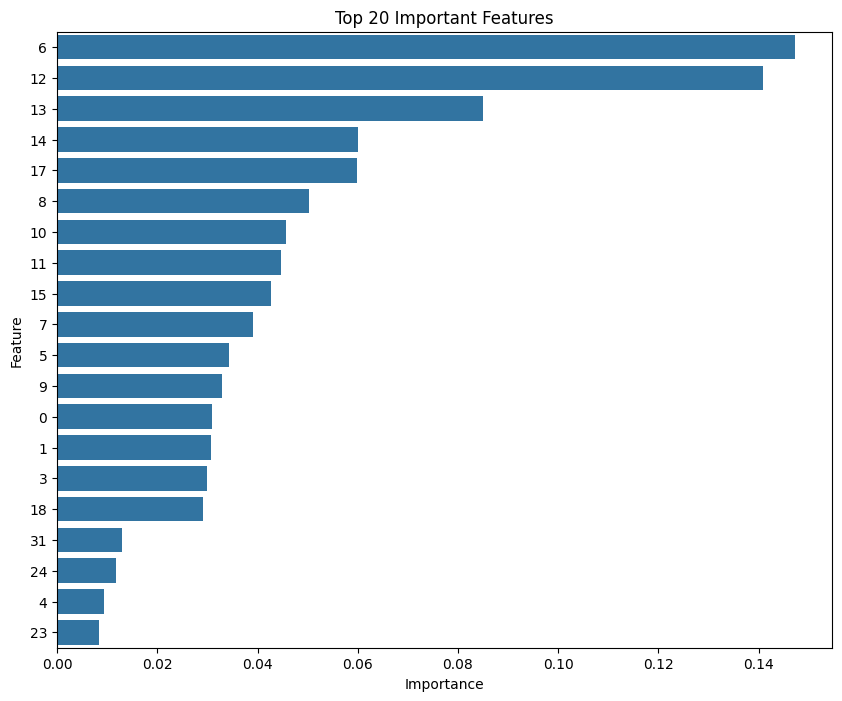

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

if hasattr(random_search.best_estimator_,"feature_importances_"):

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=importance.head(20),

        x="Importance",

        y="Feature"

    )

    plt.title("Top 20 Important Features")

    plt.show()

# 📌 Summary

This notebook:

- Tuned the Random Forest model using GridSearchCV.
- Compared Grid Search and Random Search performance.
- Selected the best hyperparameters.
- Evaluated the tuned model.
- Saved the optimized model.
- Visualized the most important features.

The tuned model can now be used for deployment in the Streamlit application.